# This notebook shows how to compute a spin-polarized STM image
### Import the necessary libraries

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from elkpy.structure import Structure

### The Tersoff-Hamann picture of a spin-polarized STM
The tunnel current from a magnetic tip is set by the sample's vacuum local density of states at the tip position, projected onto the tip magnetization $\hat{\mathbf{e}}_T$ (Wortmann, Heinze, Kurz, Bihlmayer & Blügel, PRL 86, 4132 (2001)):
$$ \frac{dI}{dV}(\mathbf{r}) \propto n(\mathbf{r},E_F+eV) + P_T\,\mathbf{m}(\mathbf{r},E_F+eV)\cdot\hat{\mathbf{e}}_T $$
with $n$ the spin-summed and $\mathbf{m}=n_\uparrow-n_\downarrow$ the vector spin-resolved LDOS, and $P_T$ the tip spin polarization.

### A non-collinear magnet: the 120-degree Néel Cr monolayer
Cr on the triangular lattice of Ag(111) orders with its three moments 120 degrees apart in the plane (Kurz, Förster, Nordström, Bihlmayer & Blügel, PRB 69, 024415 (2004)) -- the system SP-STM was proposed for. The three atoms are chemically identical, so only the spin projection can tell them apart.

In [2]:
A, C = 5.50836, 24.0  # Bohr: Cr/Ag(111) nearest-neighbour distance, 24 Bohr c-axis for vacuum
CR_AVEC = [(1.5 * A, 0.86602540378 * A, 0.0), (1.5 * A, -0.86602540378 * A, 0.0), (0.0, 0.0, C)]
# bfcmt seeds 120 degrees apart in the xy-plane; the converged moments come out antiparallel to them
CR_SPECIES = {"Cr": [((0.0, 0.0, 0.0), (0.0, 0.1, 0.0)),
                     ((1 / 3, 1 / 3, 0.0), (-0.086602540378, -0.05, 0.0)),
                     ((2 / 3, 2 / 3, 0.0), (0.086602540378, -0.05, 0.0))]}

cr = Structure(CR_AVEC, CR_SPECIES).get_calculation(
    "_scratch/cr_stm", xc="PW", spinpol=True, ngridk=(6, 6, 1),
    # nempty: non-collinearity is resolved second-variationally, so empty states are load-bearing
    # reducebf: switch the seeding fields off, so the converged Néel state is field-free
    extra_blocks={"nempty": [8], "reducebf": [0.5]},
)
cr.get_energy()

-3146.2994748139

### The image a conventional and a spin-polarized tip see
`height` is the tip plane as a fraction of the $c$ axis (0.25 of 24 Bohr = 6 Bohr above the layer), `swidth` the width of the energy window the tip samples.

Text(0, 0.5, 'y (Bohr)')

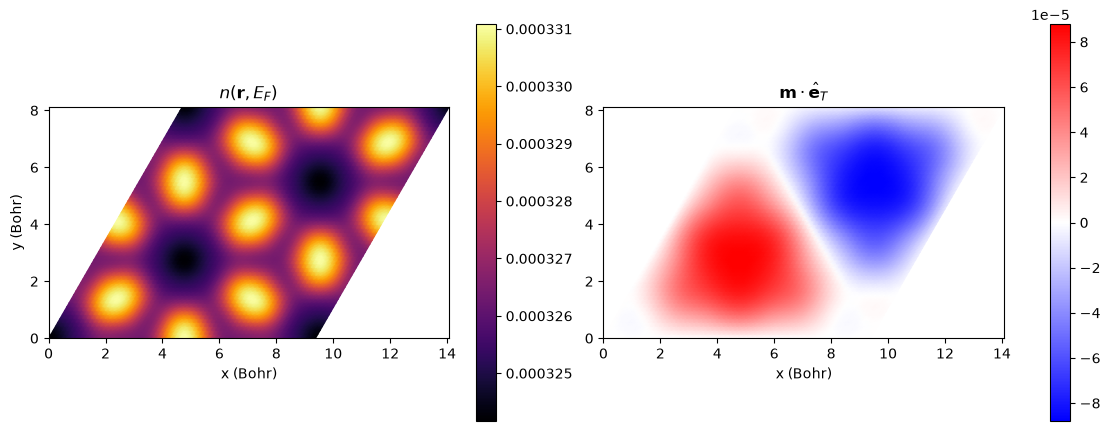

In [3]:
# one run returns all three fields: n, m.e_T, and n + P_T m.e_T
stm_x = cr.get_spin_stm(direction=(1, 0, 0), height=0.25, grid=(60, 60), swidth=0.005)
x, y = (stm_x["points"][:, i].reshape(*stm_x["grid"][::-1]) for i in (0, 1))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
for ax, key, title, cmap in [(axes[0], "ldos_grid", r"$n(\mathbf{r},E_F)$", "inferno"),
                             (axes[1], "spin_ldos_grid", r"$\mathbf{m}\cdot\hat{\mathbf{e}}_T$", "bwr")]:
    f = stm_x[key]
    v = np.abs(f).max() if cmap == "bwr" else None
    im = ax.pcolormesh(x, y, f, shading="gouraud", cmap=cmap, vmin=None if v is None else -v, vmax=v)
    fig.colorbar(im, ax=ax); ax.set_title(title); ax.set_aspect("equal"); ax.set_xlabel("x (Bohr)")
axes[0].set_ylabel("y (Bohr)")

### Rotating the tip changes which sublattice is dark
The projection above site $i$ goes as $\hat{\mathbf{u}}_i\cdot\hat{\mathbf{e}}_T$, so the three moments at 120 degrees give ratios $0:+1:-1$ for a tip along $\hat{\mathbf{x}}$ and $-1:+\tfrac12:+\tfrac12$ along $\hat{\mathbf{y}}$. The moments are coplanar in $xy$, so a tip along $\hat{\mathbf{z}}$ gives identically zero -- and that also makes $(1,1,1)$ the same image as $(1,1,0)$, only rescaled.

Text(0, 0.5, 'y (Bohr)')

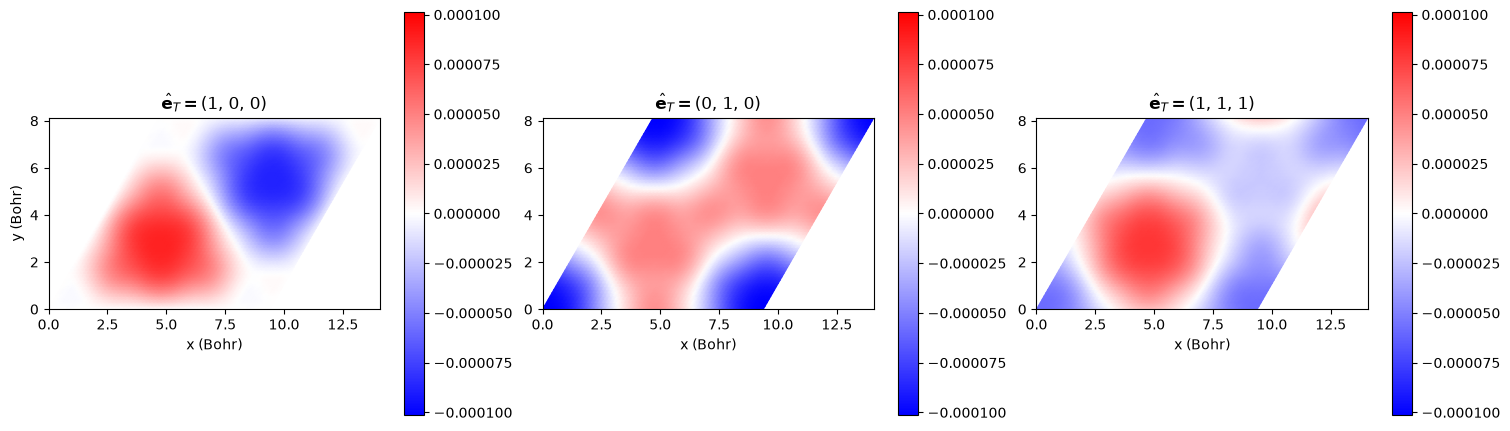

In [4]:
tips = [(1, 0, 0), (0, 1, 0), (1, 1, 1)]
images = [stm_x] + [cr.get_spin_stm(direction=d, height=0.25, grid=(60, 60), swidth=0.005)
                    for d in tips[1:]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
v = max(np.abs(r["spin_ldos"]).max() for r in images)
for ax, d, r in zip(axes, tips, images):
    im = ax.pcolormesh(x, y, r["spin_ldos_grid"], shading="gouraud", cmap="bwr", vmin=-v, vmax=v)
    fig.colorbar(im, ax=ax); ax.set_aspect("equal"); ax.set_xlabel("x (Bohr)")
    ax.set_title(r"$\hat{\mathbf{e}}_T=$" + str(d))
axes[0].set_ylabel("y (Bohr)")

### How the two contrasts compare as the tip is retracted
Each surface Fourier component of the vacuum LDOS decays as $\exp(-2z\sqrt{\kappa^2+|\mathbf{G}|^2/4})$, and the magnetic superstructure has a longer period -- smaller $|\mathbf{G}|$ -- than the chemical lattice. Over the tip heights below, the practical consequence is that the magnetic contrast stays several times larger than the chemical corrugation, which is what lets SP-STM image a magnetic structure whose spin-averaged image is nearly flat.

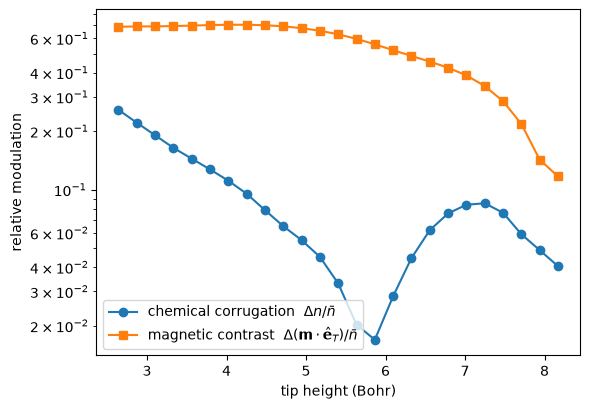

In [5]:
# one 3D run gives every tip height at once, instead of one 2D run per height
points, values = cr.get_spin_stm_3d(
    direction=(1, 0, 0), box=[(0, 0, 0.11), (1, 0, 0.11), (0, 1, 0.11), (0, 0, 0.35)],
    grid=(24, 24, 25), swidth=0.005,
)
z = np.unique(points[:, 2].round(6))
slices = [np.isclose(points[:, 2], zi) for zi in z]
mean_n = np.array([values[s, 0].mean() for s in slices])
corr_n = np.array([np.ptp(values[s, 0]) for s in slices])
corr_m = np.array([np.ptp(values[s, 1]) for s in slices])

plt.figure(figsize=(6, 4.2))
plt.semilogy(z, corr_n / mean_n, "o-", label="chemical corrugation  $\\Delta n/\\bar{n}$")
plt.semilogy(z, corr_m / mean_n, "s-", label="magnetic contrast  $\\Delta(\\mathbf{m}\\cdot\\hat{\\mathbf{e}}_T)/\\bar{n}$")
plt.xlabel("tip height (Bohr)"); plt.ylabel("relative modulation"); plt.legend(); plt.tight_layout()

### Running it straight from an `elk.in`
The same calculation is task 9003 with the `elkpy_stmdir` / `elkpy_stmpol` / `elkpy_stmbias` blocks -- see `examples/spin-stm/`, which needs no Python at all.